In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [3]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

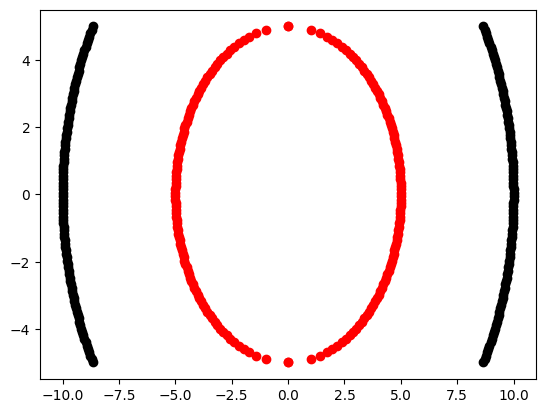

In [4]:
plt.scatter(y,x,c='black')
plt.scatter(y1,x1, c='red')

In [5]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([x,y]).T, columns=['X1','X2'])
# hstack is used to combine the upper and lower halves of the circle into one continuous set of x and y values.
# vstack(...).T is then used to arrange the data into the shape expected by ML models, where:
# each row represents one sample/data point
# each column represents one feature

df1['Y']=0
df2 = pd.DataFrame(np.vstack([x1,y1]).T, columns=['X1','X2'])
df2['Y']=1

df = pd.concat([df1,df2], ignore_index=True)
df.head()

,X1,X2,Y
0,-5.00000,8.660254,0
1,-4.89899,8.717792,0
2,-4.79798,8.773790,0
3,-4.69697,8.828277,0
4,-4.59596,8.881281,0


In [6]:
# Independent and Dependent features
X = df.iloc[:, :2]  # df.iloc[row_selection, column_selection]
y = df.Y

In [7]:
# Split the dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

### Polynomial kernel

In [8]:
# We need to find components for the Polynomical Kernel
#X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,-5.00000,8.660254,0,25.000000,75.000000,-43.301270
1,-4.89899,8.717792,0,24.000102,75.999898,-42.708375
2,-4.79798,8.773790,0,23.020610,76.979390,-42.096467
3,-4.69697,8.828277,0,22.061524,77.938476,-41.466150
4,-4.59596,8.881281,0,21.122845,78.877155,-40.818009


In [9]:
# Independent and Dependent features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [25]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,0.050505,4.999745,0.002551,24.997449,0.252512
63,1.363636,9.906589,1.859504,98.140496,13.508984
312,3.787879,-3.263736,14.348026,10.651974,-12.362637
159,-0.959596,-9.953852,0.920824,99.079176,9.551676
283,3.383838,3.680983,11.450362,13.549638,12.455852
...,...,...,...,...,...
323,2.676768,-4.223140,7.165085,17.834915,-11.304366
192,-4.292929,-9.031653,18.429242,81.570758,38.772248
117,3.282828,-9.445795,10.776962,89.223038,-31.008922
47,-0.252525,9.996811,0.063769,99.936231,-2.524447


In [26]:
y_train

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

In [27]:
import plotly.express as px
fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',color='Y')
fig.show()

In [28]:
fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',color='Y')
fig.show()

In [29]:
X

,X1,X2,X1_Square,X2_Square,X1*X2
0,-5.00000,8.660254,25.000000,75.000000,-43.301270
1,-4.89899,8.717792,24.000102,75.999898,-42.708375
2,-4.79798,8.773790,23.020610,76.979390,-42.096467
3,-4.69697,8.828277,22.061524,77.938476,-41.466150
4,-4.59596,8.881281,21.122845,78.877155,-40.818009
...,...,...,...,...,...
395,-4.59596,-1.969049,21.122845,3.877155,9.049671
396,-4.69697,-1.714198,22.061524,2.938476,8.051537
397,-4.79798,-1.406908,23.020610,1.979390,6.750316
398,-4.89899,-0.999949,24.000102,0.999898,4.898740


In [30]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0